# London Rents: Building a Regression Model Step by Step

## What is this notebook about?

We want to answer a simple question:
**What drives the monthly rent of a London flat?**

We start with one predictor, size, and then add more, one step at a time, watching what happens to the coefficients, R², adjusted R² and the residual standard error. It follows the lecture slides and the Regression Lab app, so every number here matches what you saw in class.

The data are 150 London rental listings in `london_rents.csv` (in this folder).

| Variable | What it means |
|---|---|
| `rent` | Monthly rent in £ *(the outcome we want to explain and predict)* |
| `size_sqm` | Floor area in square metres |
| `bedrooms` | Number of bedrooms (0 for a studio) |
| `zone` | TfL travel zone, 1 to 4 (a category, not a number) |
| `type` | Flat, House or Studio |
| `furnished` | Yes or No |
| `parking` | Yes or No: does the listing come with a parking space? |
| `mins_to_tube` | Walking minutes to the nearest tube station |
| `lucky_number` | A random number from 1 to 99. It has nothing to do with rent, on purpose |

---

## Key vocabulary

- **OLS (Ordinary Least Squares)**: finds the line that makes the sum of squared errors as small as possible.
- **R²**: the share of the variation in rent the model explains, from 0 to 1.
- **Adjusted R²**: R² with a penalty for each extra predictor. Use it to compare models with different numbers of predictors.
- **Residual SE**: the typical size of a miss, in £.
- **Dummy variable**: a 0/1 column that lets a category such as parking or zone enter the model.
- **Base (reference) category**: the level of a category that gets no dummy; the other coefficients are differences from it.
- **Omitted variable bias**: a coefficient is wrong because a variable that matters, and is correlated with it, was left out.
- **Multicollinearity**: two predictors so strongly correlated that the model cannot split the credit between them. **VIF** above 5 to 10 is a warning sign.

---

## Models we build

| Model | Formula | Purpose |
|---|---|---|
| M0 | `rent ~ 1` | Baseline: predict the average rent for everyone |
| M1 | `rent ~ size_sqm` | Does size alone explain rent? |
| M2 | `rent ~ size_sqm + parking` | A first dummy: does a parking space shift the line? |
| M2b | `rent ~ size_sqm + parking + type` | Is the parking premium real, or partly a house effect? |
| M3 | `rent ~ size_sqm + zone` | A category with four levels, and the size slope jumps |
| M4 | size + zone + type + furnished + parking + mins_to_tube | The full additive model |
| M5 | M4 + lucky_number | R² against adjusted R² |
| M6 | `rent ~ size_sqm + bedrooms` | Collinearity and VIF |
| M7 | M4 + size × furnished + parking × zone | Optional: interactions |

## Section 1: Import libraries

| Package | What we use it for |
|---|---|
| `pandas` (pd) | Tables of data (DataFrames) |
| `numpy` (np) | Maths and arrays |
| `seaborn` (sns), `matplotlib.pyplot` (plt) | Charts |
| `scipy.stats` | The Q-Q plot of residuals |
| `statsmodels.formula.api` (smf) | OLS regression with R-style formulas such as `'rent ~ size_sqm'` |
| `summary_col` | Side-by-side table of several models |
| `variance_inflation_factor` | The VIF check for collinearity |

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # hide harmless deprecation warnings

from scipy import stats                                   # Q-Q probability plot
import statsmodels.api as sm
import statsmodels.formula.api as smf                     # OLS with R-style formulas
from statsmodels.iolib.summary2 import summary_col        # side-by-side model table
from statsmodels.stats.outliers_influence import variance_inflation_factor  # VIF

## Section 2: Helper function `fit_and_plot`

Rather than repeat the same code for every model, we write it once. The function:

1. **Fits** an OLS model from a formula.
2. **Prints** a compact table: R², adjusted R², residual SE, and each coefficient with its standard error, t and p-value. Stars mark significance: `***` p < 0.001, `**` p < 0.01, `*` p < 0.05, `.` p < 0.1.
3. **Draws** three charts:
   - **Top**: actual against predicted rent, with the chosen x variable on the horizontal axis.
   - **Bottom left**: residuals against fitted values. We want a shapeless cloud around zero.
   - **Bottom right**: a Q-Q plot. If the residuals are roughly normal, the dots sit near the line.

In [2]:
def fit_and_plot(formula, data, model_name="Model", x_var=None):
    model = smf.ols(formula=formula, data=data).fit()

    # Compact summary
    rse = np.sqrt(model.mse_resid)
    print(f"\n{'='*62}")
    print(f"  {model_name}")
    print(f"{'='*62}")
    print(f"  R²: {model.rsquared:.4f}    Adj R²: {model.rsquared_adj:.4f}    Residual SE: {rse:.2f}")
    print(f"  Observations: {int(model.nobs)}    df residual: {int(model.df_resid)}")
    print(f"{'-'*62}")
    print(f"  {'Coefficient':<26} {'Estimate':>10} {'Std Err':>9} {'t':>7} {'P>|t|':>7}")
    print(f"{'-'*62}")
    for name, coef, se, tval, pval in zip(model.params.index, model.params,
                                          model.bse, model.tvalues, model.pvalues):
        sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "." if pval < 0.1 else ""
        print(f"  {name:<26} {coef:>10.2f} {se:>9.2f} {tval:>7.2f} {pval:>7.4f} {sig}")
    print(f"{'='*62}\n")

    if x_var is None:
        x_var = formula.split('~')[1].strip().split('+')[0].strip()

    y_var     = formula.split('~')[0].strip()
    residuals = model.resid
    is_cat    = data[x_var].dtype == object or str(data[x_var].dtype) == 'category'

    fig = plt.figure(figsize=(15, 10))
    gs  = fig.add_gridspec(2, 2, height_ratios=[1.6, 1], hspace=0.35, wspace=0.3)
    ax_main = fig.add_subplot(gs[0, :])
    ax_res  = fig.add_subplot(gs[1, 0])
    ax_qq   = fig.add_subplot(gs[1, 1])

    # 1. Actual vs predicted
    if is_cat:
        sns.stripplot(x=data[x_var], y=data[y_var],
                      alpha=0.3, color='black', s=4, ax=ax_main, label='Actual')
        group_means = data.groupby(x_var)[y_var].mean()
        ax_main.hlines(group_means.values,
                       xmin=[i - 0.3 for i in range(len(group_means))],
                       xmax=[i + 0.3 for i in range(len(group_means))],
                       colors='red', linewidth=2, label='Predicted mean')
    else:
        ax_main.scatter(data[x_var], data[y_var],
                        alpha=0.3, color='black', s=15, label='Actual')
        ax_main.scatter(data[x_var], model.fittedvalues,
                        alpha=0.3, color='red', s=15, label='Predicted')

    ax_main.set_title(f'Actual vs predicted, x: {x_var}', fontsize=13)
    ax_main.set_xlabel(x_var)
    ax_main.set_ylabel(y_var)
    ax_main.legend()

    # 2. Residuals vs fitted
    ax_res.scatter(model.fittedvalues, residuals, alpha=0.3, color='steelblue', s=15)
    ax_res.axhline(0, color='red', linewidth=1, linestyle='--')
    ax_res.set_title('Residuals vs fitted', fontsize=11)
    ax_res.set_xlabel('Fitted values')
    ax_res.set_ylabel('Residuals')

    # 3. Q-Q plot
    (osm, osr), (slope, intercept, _) = stats.probplot(residuals, dist='norm')
    ax_qq.scatter(osm, osr, alpha=0.3, color='steelblue', s=15)
    ax_qq.plot(osm, slope * np.array(osm) + intercept, color='red', linewidth=1, linestyle='--')
    ax_qq.set_title('Q-Q plot of residuals', fontsize=11)
    ax_qq.set_xlabel('Theoretical quantiles')
    ax_qq.set_ylabel('Sample quantiles')

    plt.suptitle(
        f'{model_name}  |  R² = {model.rsquared:.3f}  |  Adj R² = {model.rsquared_adj:.3f}  |  Residual SE = {rse:.0f}',
        fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    return model

## Section 3: Load and inspect the data

The file `london_rents.csv` sits in the same folder as this notebook.

One detail matters: `zone` is stored as 1, 2, 3, 4, but it is a **category**, not a quantity. Zone 4 is not "four times" zone 1. We read it as text (`dtype={'zone': str}`) so statsmodels will turn it into dummies rather than fit one straight-line effect.

In [3]:
# Read the data. zone is read as text so that it is treated as a category.
rents = pd.read_csv("london_rents.csv", dtype={'zone': str})

print(f"Shape: {rents.shape}")
rents.info()

Shape: (150, 10)
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id            150 non-null    int64
 1   rent          150 non-null    int64
 2   size_sqm      150 non-null    int64
 3   bedrooms      150 non-null    int64
 4   zone          150 non-null    str  
 5   type          150 non-null    str  
 6   furnished     150 non-null    str  
 7   parking       150 non-null    str  
 8   mins_to_tube  150 non-null    int64
 9   lucky_number  150 non-null    int64
dtypes: int64(6), str(4)
memory usage: 11.8 KB


In [4]:
rents.head()

,id,rent,size_sqm,bedrooms,zone,type,furnished,parking,mins_to_tube,lucky_number
0,1,2860,67,3,2,House,Yes,Yes,6,22
1,2,1850,64,2,3,Flat,No,No,14,31
2,3,2390,65,2,1,House,No,Yes,14,6
3,4,1540,53,2,2,Flat,Yes,No,15,8
4,5,1430,67,3,2,Flat,No,No,27,36


### Summary statistics

- Average rent is about **£1,855** a month, from £650 to £3,740.
- Sizes run from **19 to 122 m²**, with an average of about 57 m².
- `lucky_number` is spread evenly from 1 to 99, as you would expect from a random number.

In [5]:
rents.describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
id,150.0,75.5,43.4,1.0,38.2,75.5,112.8,150.0
rent,150.0,1854.6,673.8,650.0,1352.5,1845.0,2270.0,3740.0
size_sqm,150.0,57.4,20.4,19.0,45.2,59.0,70.8,122.0
bedrooms,150.0,2.1,1.1,0.0,2.0,2.0,3.0,5.0
mins_to_tube,150.0,15.1,9.9,1.0,8.0,14.0,19.8,40.0
lucky_number,150.0,50.5,27.8,2.0,27.0,47.0,76.0,99.0


In [6]:
# How many listings fall into each category?
for col in ['zone', 'type', 'furnished', 'parking']:
    print(rents[col].value_counts().sort_index().to_string(), '\n')

zone
1    33
2    46
3    47
4    24 

type
Flat      98
House     29
Studio    23 

furnished
No     86
Yes    64 

parking
No     83
Yes    67 



## Section 4: Correlation heatmap

Before modelling, look at the pairwise correlations between the numeric variables.

What to notice:
- `size_sqm` has the strongest correlation with rent (about **0.52**).
- `size_sqm` and `bedrooms` correlate at about **0.96**. That is a warning sign for collinearity, which we come back to in Section 11.
- `lucky_number` correlates with nothing, as it should.

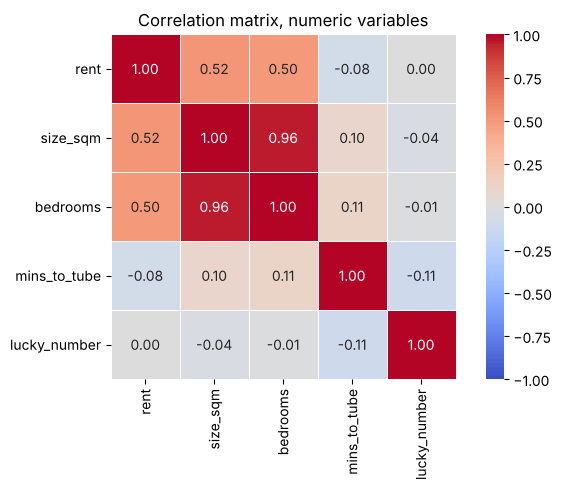

In [7]:
numeric = ['rent', 'size_sqm', 'bedrooms', 'mins_to_tube', 'lucky_number']

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(rents[numeric].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation matrix, numeric variables')
plt.tight_layout()
plt.show()

## Section 5: Model 0, intercept only (baseline)

The simplest possible model predicts the same rent for everyone: the average, about £1,855.

- **R² = 0** by definition: it explains none of the variation.
- **Intercept** = the sample mean of rent.
- Any useful predictor has to beat this.

In [8]:
# 'rent ~ 1' means: predict rent using only an intercept (the mean).
model0 = smf.ols('rent ~ 1', data=rents).fit()
print(f"Intercept (mean rent): {model0.params['Intercept']:.1f}")
print(f"Residual SE: {np.sqrt(model0.mse_resid):.1f}   (this is just the standard deviation of rent)")

Intercept (mean rent): 1854.6
Residual SE: 673.8   (this is just the standard deviation of rent)


## Section 6: Model 1, rent ~ size

Our first real model. We expect a **positive** slope: bigger homes cost more.

What to look for in the output:
- **Intercept ≈ 866**: where the line meets zero size. No flat has zero size, so read it as the line's starting height, not a real rent.
- **Slope ≈ 17.2**: every extra square metre adds about **£17 a month** on average.
- **t ≈ 7.4, p < 0.001**: the slope is clearly not zero.
- **R² ≈ 0.27**: size explains only about a quarter of the variation in rent. Size matters, but it is one driver among several.


  M1: rent ~ size
  R²: 0.2715    Adj R²: 0.2666    Residual SE: 577.05
  Observations: 150    df residual: 148
--------------------------------------------------------------
  Coefficient                  Estimate   Std Err       t   P>|t|
--------------------------------------------------------------
  Intercept                      866.34    141.16    6.14  0.0000 ***
  size_sqm                        17.22      2.32    7.43  0.0000 ***



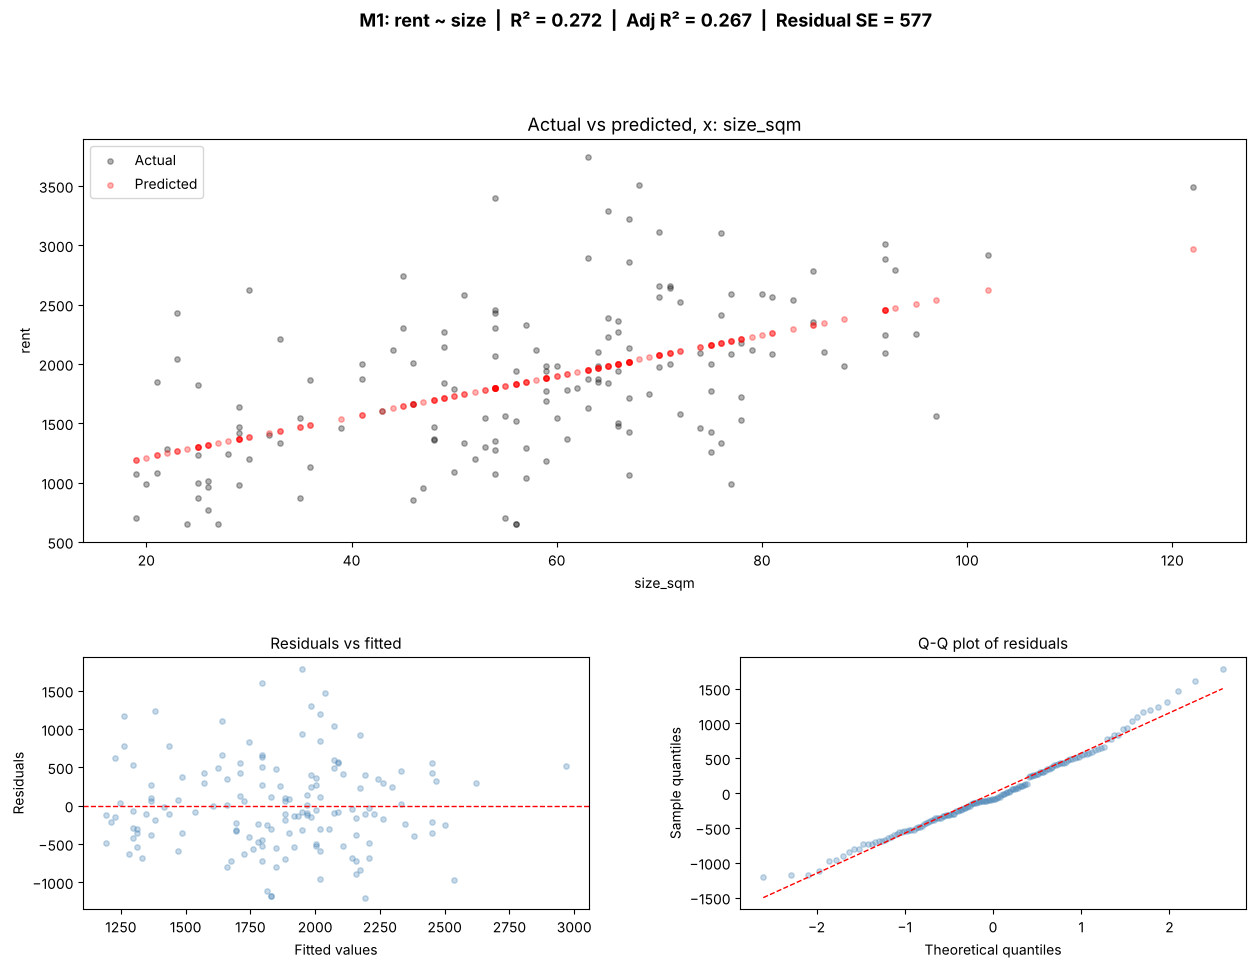

In [9]:
model1 = fit_and_plot('rent ~ size_sqm', data=rents,
                      model_name='M1: rent ~ size', x_var='size_sqm')

### The full statsmodels output

This is the table you will see most often in practice. The confidence interval for the slope runs from about £12.6 to £21.8 per m².

In [10]:
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                   rent   R-squared:                       0.272
Model:                            OLS   Adj. R-squared:                  0.267
Method:                 Least Squares   F-statistic:                     55.16
Date:                Thu, 08 Oct 2026   Prob (F-statistic):           8.15e-12
Time:                        17:22:08   Log-Likelihood:                -1165.5
No. Observations:                 150   AIC:                             2335.
Df Residuals:                     148   BIC:                             2341.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    866.3353    141.159      6.137      0.0

### SST = SSR + SSE, and R² = r²

- **SST**: total variation of rent around its mean.
- **SSR**: the part the line explains.
- **SSE**: the part left in the residuals.

R² = SSR / SST. With a single predictor, R² is also the correlation between x and y, squared.

In [11]:
sst = ((rents['rent'] - rents['rent'].mean())**2).sum()
sse = (model1.resid**2).sum()
ssr = sst - sse
r = rents['rent'].corr(rents['size_sqm'])

print(f"SST = {sst:,.0f}")
print(f"SSR = {ssr:,.0f}")
print(f"SSE = {sse:,.0f}")
print(f"R² = SSR / SST = {ssr/sst:.3f}")
print(f"r = {r:.3f},  r² = {r**2:.3f}")
print(f"Sum of residuals = {model1.resid.sum():.6f}   (always zero for OLS with an intercept)")

SST = 67,648,926
SSR = 18,367,475
SSE = 49,281,451
R² = SSR / SST = 0.272
r = 0.521,  r² = 0.272
Sum of residuals = -0.000000   (always zero for OLS with an intercept)


## Section 7: Augment the data with predictions, and predict a new flat

`.get_prediction()` gives predicted values **plus uncertainty intervals**:
- `mean`: the model's point prediction (the fitted value)
- `mean_ci_lower/upper`: 95% confidence interval for the *average* rent of flats like this one
- `obs_ci_lower/upper`: 95% prediction interval for *one new listing*, always wider

Then we predict a 60 m² flat. The quick rule of thumb is prediction ± 2 × residual SE.

In [12]:
predictions_df = model1.get_prediction(rents).summary_frame(alpha=0.05)
rents_augmented = rents.join(predictions_df)
rents_augmented['residual'] = model1.resid

print("Columns added:", predictions_df.columns.tolist())
rents_augmented[['rent', 'size_sqm', 'mean', 'residual', 'obs_ci_lower', 'obs_ci_upper']].head().round(0)

Columns added: ['mean', 'mean_se', 'mean_ci_lower', 'mean_ci_upper', 'obs_ci_lower', 'obs_ci_upper']


,rent,size_sqm,mean,residual,obs_ci_lower,obs_ci_upper
0,2860,67,2020.0,840.0,875.0,3165.0
1,1850,64,1968.0,-118.0,824.0,3113.0
2,2390,65,1986.0,404.0,841.0,3130.0
3,1540,53,1779.0,-239.0,635.0,2923.0
4,1430,67,2020.0,-590.0,875.0,3165.0


In [13]:
new_flat = pd.DataFrame({'size_sqm': [60]})
pred = model1.get_prediction(new_flat).summary_frame(alpha=0.05)
rse1 = np.sqrt(model1.mse_resid)

print(f"Predicted rent for 60 m²: £{pred['mean'].iloc[0]:,.0f}")
print(f"Rule of thumb, ± 2 × {rse1:.0f}: £{pred['mean'].iloc[0] - 2*rse1:,.0f} to £{pred['mean'].iloc[0] + 2*rse1:,.0f}")
print(f"Exact 95% prediction interval: £{pred['obs_ci_lower'].iloc[0]:,.0f} to £{pred['obs_ci_upper'].iloc[0]:,.0f}")

Predicted rent for 60 m²: £1,899
Rule of thumb, ± 2 × 577: £745 to £3,054
Exact 95% prediction interval: £755 to £3,044


A range of more than £2,000 is far too wide to set a rent with. To narrow it, we need more predictors.

## Section 8: Model 2, a first dummy: parking

`parking` is Yes or No. statsmodels turns it into a 0/1 dummy, `parking[T.Yes]`, with **No** as the base.

The model becomes:
```
rent = intercept + b1 × size + b2 × (1 if parking, else 0)
```

So listings with parking get a line that is shifted up by b2, with the **same slope**. Two parallel lines.

What to look for:
- **parking[T.Yes] ≈ 289**: a parking space adds about £289 a month for a listing of the same size (p ≈ 0.003).
- **Adjusted R²** rises from 0.267 to about 0.306.


  M2: rent ~ size + parking
  R²: 0.3152    Adj R²: 0.3059    Residual SE: 561.38
  Observations: 150    df residual: 147
--------------------------------------------------------------
  Coefficient                  Estimate   Std Err       t   P>|t|
--------------------------------------------------------------
  Intercept                      821.82    138.09    5.95  0.0000 ***
  parking[T.Yes]                 288.64     94.27    3.06  0.0026 **
  size_sqm                        15.75      2.31    6.83  0.0000 ***



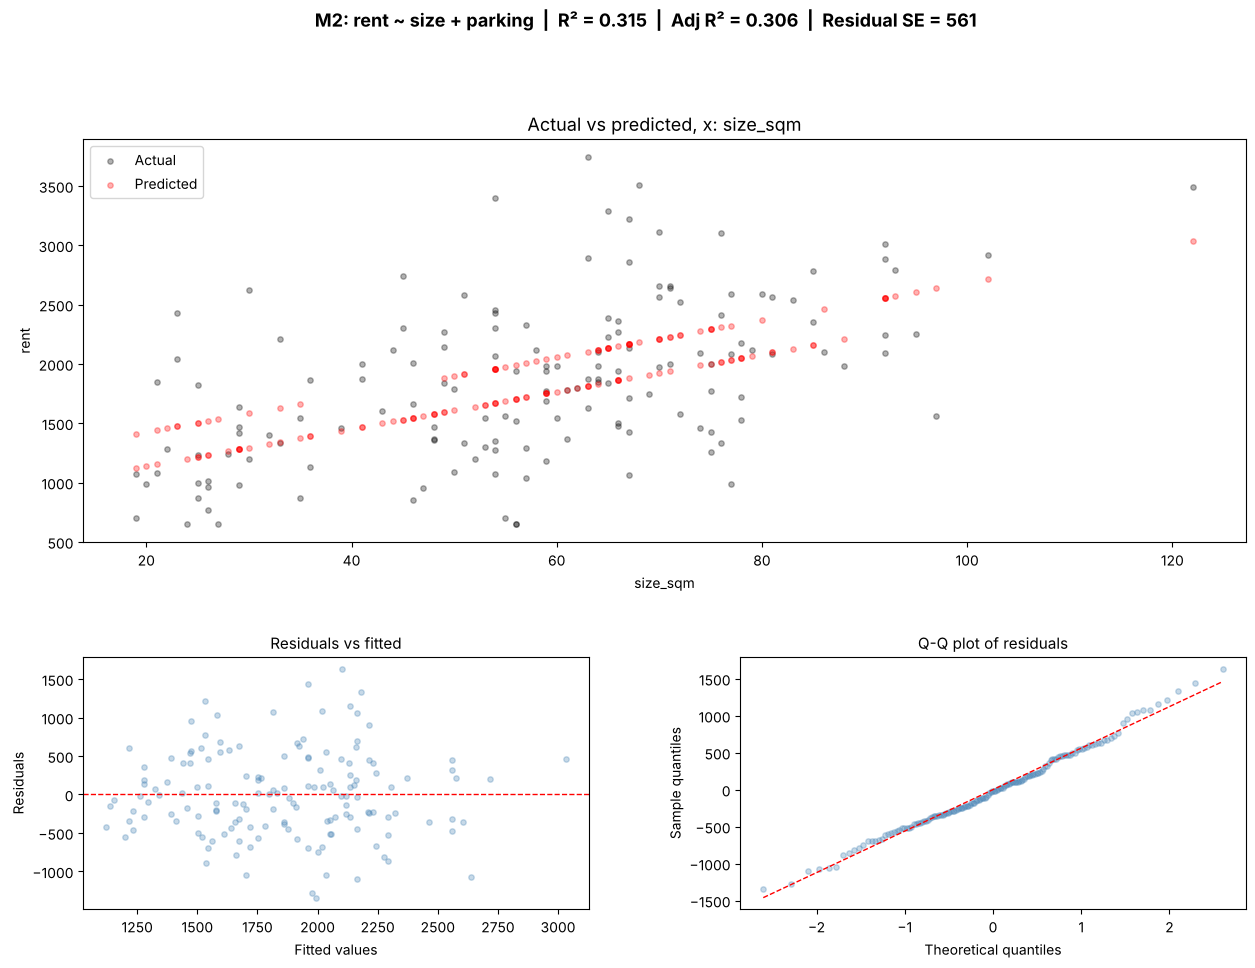

In [14]:
model2 = fit_and_plot('rent ~ size_sqm + parking', data=rents,
                      model_name='M2: rent ~ size + parking', x_var='size_sqm')

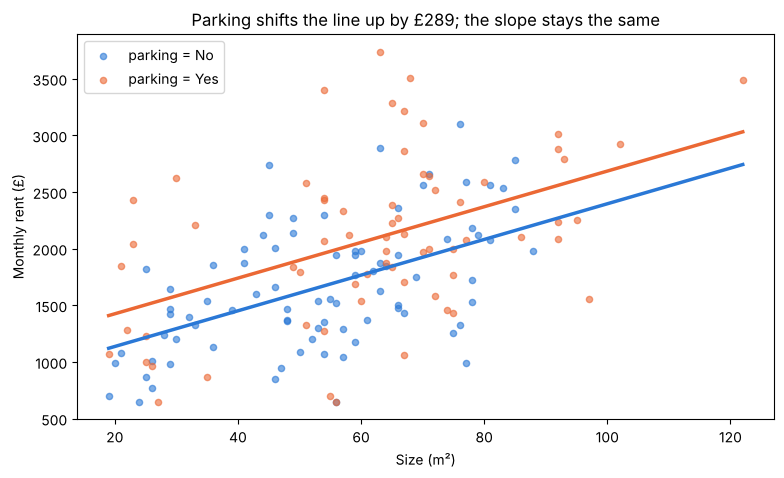

In [15]:
# Draw the two parallel lines
b = model2.params
fig, ax = plt.subplots(figsize=(9, 5))
colours = {'No': '#2a78d6', 'Yes': '#eb6834'}
xs = np.linspace(rents['size_sqm'].min(), rents['size_sqm'].max(), 50)
for level, colour in colours.items():
    d = rents[rents['parking'] == level]
    ax.scatter(d['size_sqm'], d['rent'], color=colour, alpha=0.6, s=20, label=f'parking = {level}')
    shift = b['parking[T.Yes]'] if level == 'Yes' else 0
    ax.plot(xs, b['Intercept'] + shift + b['size_sqm'] * xs, color=colour, linewidth=2.5)
ax.set_xlabel('Size (m²)'); ax.set_ylabel('Monthly rent (£)')
ax.set_title(f"Parking shifts the line up by £{b['parking[T.Yes]']:.0f}; the slope stays the same")
ax.legend()
plt.show()

### Model 2b: is a parking space really worth £289?

Most houses come with parking, and houses rent for more anyway. If we leave property type out, parking may be taking credit for being a house. Let's check.

In [16]:
# Share of each property type that comes with parking
pd.crosstab(rents['type'], rents['parking'], normalize='index').round(2)

parking,No,Yes
type,,
Flat,0.64,0.36
House,0.21,0.79
Studio,0.61,0.39


In [17]:
model2b = smf.ols('rent ~ size_sqm + parking + type', data=rents).fit()
print(model2b.summary().tables[1])
print(f"\nParking premium without type: £{model2.params['parking[T.Yes]']:.0f}")
print(f"Parking premium with type:    £{model2b.params['parking[T.Yes]']:.0f}  (p = {model2b.pvalues['parking[T.Yes]']:.3f})")

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       1237.5814    186.808      6.625      0.000     868.362    1606.801
parking[T.Yes]   153.9408     89.119      1.727      0.086     -22.200     330.082
type[T.House]    723.5533    122.509      5.906      0.000     481.419     965.688
type[T.Studio]  -212.3560    156.585     -1.356      0.177    -521.841      97.129
size_sqm           7.6826      3.035      2.531      0.012       1.684      13.681

Parking premium without type: £289
Parking premium with type:    £154  (p = 0.086)


### Finding

The premium roughly halves, to about **£154**, and is no longer significant at 5% (p ≈ 0.086). 23 of the 29 houses have parking, against about a third of flats and studios. Part of the "parking effect" was really a "house effect". This is our first look at **omitted variable bias**.

## Section 9: Model 3, a category with four levels: zone

`zone` has four levels, so statsmodels creates **three** dummies: `zone[T.2]`, `zone[T.3]`, `zone[T.4]`. Zone 1 is the base and gets no column.

Each zone coefficient is the gap to zone 1 for a listing of the **same size**. The picture is four parallel lines.


  M3: rent ~ size + zone
  R²: 0.5603    Adj R²: 0.5481    Residual SE: 452.94
  Observations: 150    df residual: 145
--------------------------------------------------------------
  Coefficient                  Estimate   Std Err       t   P>|t|
--------------------------------------------------------------
  Intercept                      992.83    118.91    8.35  0.0000 ***
  zone[T.2]                     -564.55    105.38   -5.36  0.0000 ***
  zone[T.3]                     -929.23    112.83   -8.24  0.0000 ***
  zone[T.4]                    -1183.00    132.00   -8.96  0.0000 ***
  size_sqm                        26.40      2.06   12.83  0.0000 ***



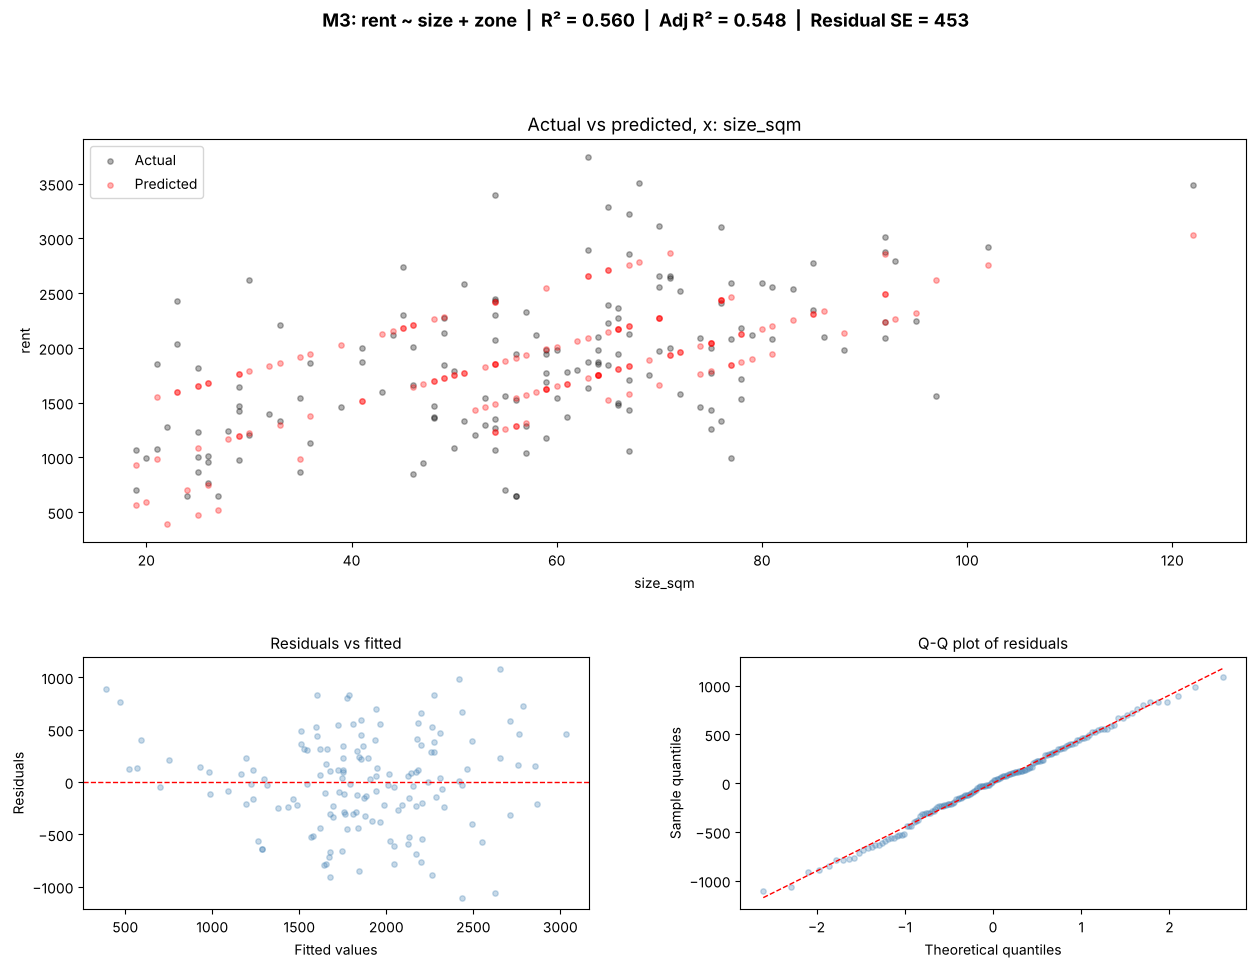

In [18]:
model3 = fit_and_plot('rent ~ size_sqm + zone', data=rents,
                      model_name='M3: rent ~ size + zone', x_var='size_sqm')

### The size slope jumps from £17 to £26

Compare the size coefficient in Model 1 (about 17.2) with Model 3 (about 26.4). Why does adding zone change the effect of size?

Because bigger flats tend to be further out, where every square metre is cheaper. With zone left out, size gets blamed for being in zone 4. This is the same story as study time and IQ in the confounding slides.

In [19]:
print(f"Size slope, size only:   £{model1.params['size_sqm']:.1f} per m²")
print(f"Size slope, size + zone: £{model3.params['size_sqm']:.1f} per m²\n")

# Bigger flats are further out, where rent per m² is lower
rents.groupby('zone')[['size_sqm', 'rent']].mean().round(0)

Size slope, size only:   £17.2 per m²
Size slope, size + zone: £26.4 per m²



,size_sqm,rent
zone,,
1,43.0,2135.0
2,53.0,1836.0
3,66.0,1800.0
4,68.0,1613.0


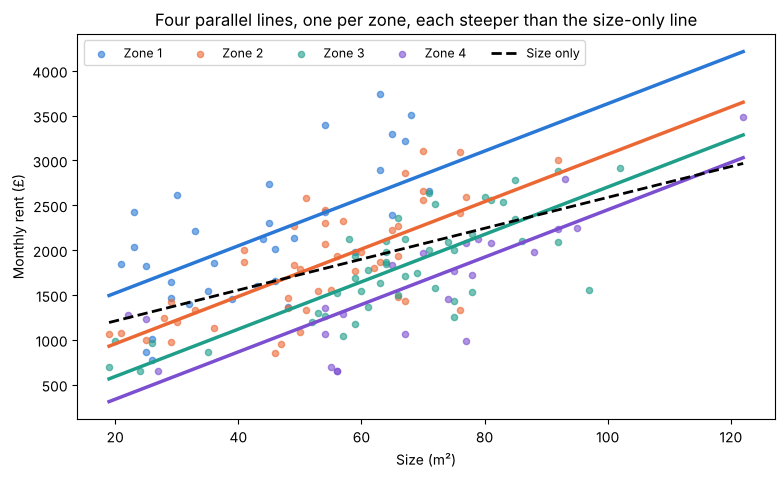

In [20]:
# Four parallel lines, one per zone
b = model3.params
zone_colours = {'1': '#2a78d6', '2': '#eb6834', '3': '#1f9e89', '4': '#7b4fd0'}
fig, ax = plt.subplots(figsize=(9, 5))
for z, colour in zone_colours.items():
    d = rents[rents['zone'] == z]
    shift = 0 if z == '1' else b[f'zone[T.{z}]']
    ax.scatter(d['size_sqm'], d['rent'], color=colour, alpha=0.6, s=20, label=f'Zone {z}')
    ax.plot(xs, b['Intercept'] + shift + b['size_sqm'] * xs, color=colour, linewidth=2.5)
# The size-only line, for comparison
ax.plot(xs, model1.params['Intercept'] + model1.params['size_sqm'] * xs,
        color='black', linestyle='--', linewidth=2, label='Size only')
ax.set_xlabel('Size (m²)'); ax.set_ylabel('Monthly rent (£)')
ax.set_title('Four parallel lines, one per zone, each steeper than the size-only line')
ax.legend(ncol=5, fontsize=9)
plt.show()

### Change the base, not the answer

We can pick any zone as the base with `C(zone, Treatment(reference='4'))`. Every zone coefficient changes, because each is now a difference from zone 4. But the fitted rents, R² and predictions stay exactly the same.

In [21]:
model3_base4 = smf.ols("rent ~ size_sqm + C(zone, Treatment(reference='4'))", data=rents).fit()

def zone_effects(m, base):
    # Collect each zone's coefficient by name; the base zone shows 0
    out = {'Intercept': m.params['Intercept'], 'size_sqm': m.params['size_sqm']}
    for z in ['1', '2', '3', '4']:
        key = [k for k in m.params.index if k.endswith(f'[T.{z}]')]
        out[f'Zone {z}'] = m.params[key[0]] if key else 0.0
    return pd.Series(out)

print(pd.DataFrame({'base = zone 1': zone_effects(model3, '1'),
                    'base = zone 4': zone_effects(model3_base4, '4')}).round(1))
print(f"\nR², base zone 1: {model3.rsquared:.4f}")
print(f"R², base zone 4: {model3_base4.rsquared:.4f}")
print(f"Largest difference in fitted values: {np.abs(model3.fittedvalues - model3_base4.fittedvalues).max():.2e}")

           base = zone 1  base = zone 4
Intercept          992.8         -190.2
size_sqm            26.4           26.4
Zone 1               0.0         1183.0
Zone 2            -564.6          618.4
Zone 3            -929.2          253.8
Zone 4           -1183.0            0.0

R², base zone 1: 0.5603
R², base zone 4: 0.5603
Largest difference in fitted values: 1.09e-11


### What if we treat zone as a number?

`zone.astype(int)` forces one equal step between zones. The real steps are uneven, so the fit is slightly worse. When is a number really a category? When the gaps between its values are not equal.

In [22]:
model3_num = smf.ols('rent ~ size_sqm + zone.astype(int)', data=rents).fit()
print(f"Zone as a category: R² = {model3.rsquared:.3f}")
print(f"Zone as a number:   R² = {model3_num.rsquared:.3f}, rent falls by £{-model3_num.params['zone.astype(int)']:.0f} for every zone further out")

Zone as a category: R² = 0.560
Zone as a number:   R² = 0.548, rent falls by £395 for every zone further out


**The dummy trap.** We cannot include all four zone dummies plus an intercept: the four columns always add up to the intercept column, so there is no unique answer. statsmodels avoids this by dropping the base level for you.

## Section 10: Model 4, the full additive model, and Model 5, a noise variable

Now we put everything in. Each coefficient is the effect of that variable **holding all the others fixed**.

What to look for:
- Size, zone, house, furnished and parking are all significant.
- `mins_to_tube` is **not** significant (p ≈ 0.48). The data were built with a real effect of −£8 a minute, but with this much noise 150 listings cannot see it. Not significant is not the same as no effect.
- Adjusted R² reaches about **0.67**, and the residual SE falls to about **£385**.


  M4: full additive model
  R²: 0.6930    Adj R²: 0.6732    Residual SE: 385.17
  Observations: 150    df residual: 140
--------------------------------------------------------------
  Coefficient                  Estimate   Std Err       t   P>|t|
--------------------------------------------------------------
  Intercept                      930.73    160.85    5.79  0.0000 ***
  zone[T.2]                     -497.46     91.55   -5.43  0.0000 ***
  zone[T.3]                     -829.30    104.36   -7.95  0.0000 ***
  zone[T.4]                    -1102.74    126.65   -8.71  0.0000 ***
  type[T.House]                  307.61    102.58    3.00  0.0032 **
  type[T.Studio]                  52.05    124.99    0.42  0.6778 
  furnished[T.Yes]               270.27     65.62    4.12  0.0001 ***
  parking[T.Yes]                 295.11     70.08    4.21  0.0000 ***
  size_sqm                        21.53      2.81    7.65  0.0000 ***
  mins_to_tube                    -2.49      3.49   -0.71  0.

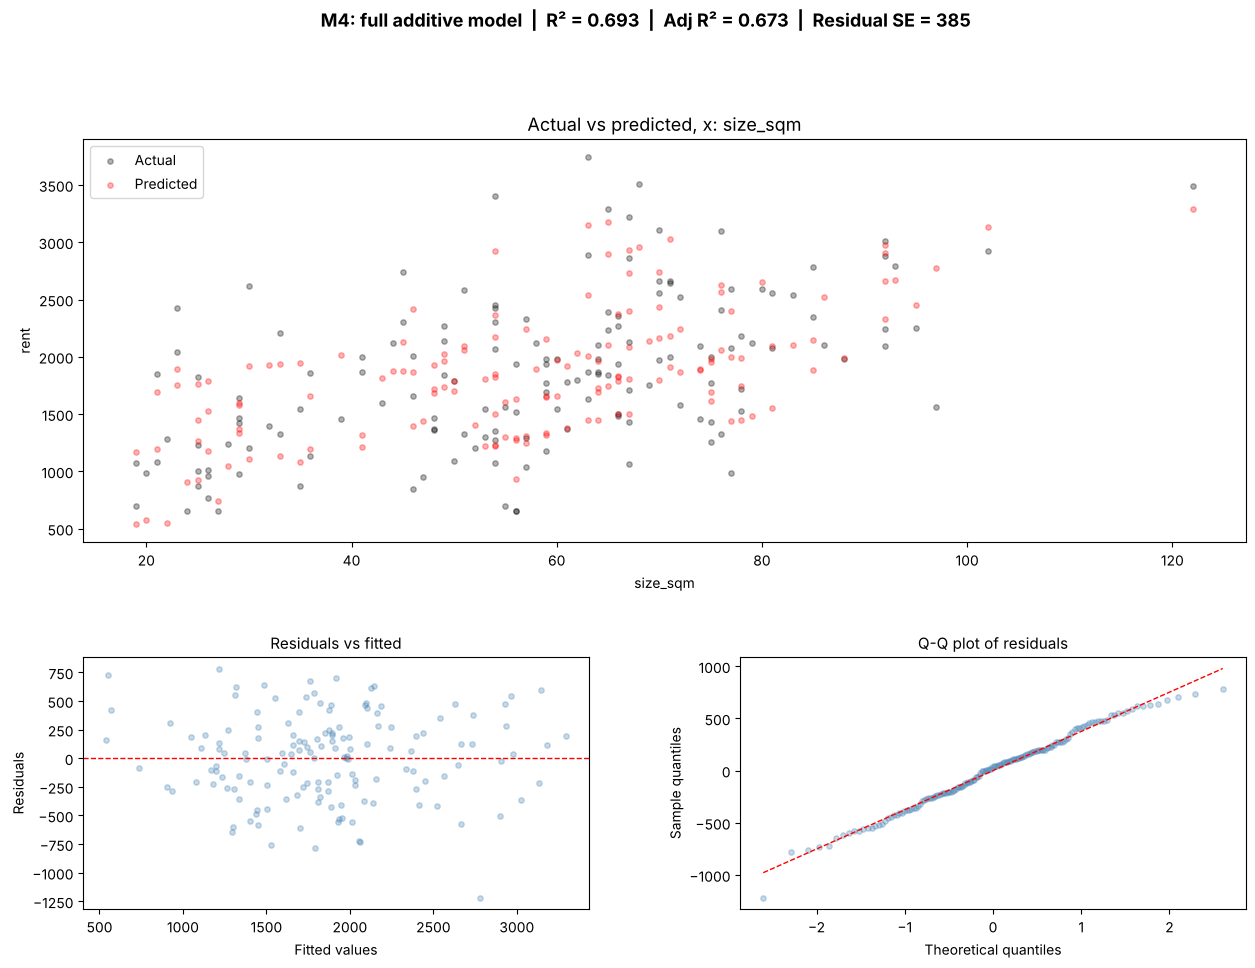

In [23]:
full = 'rent ~ size_sqm + zone + type + furnished + parking + mins_to_tube'
model4 = fit_and_plot(full, data=rents, model_name='M4: full additive model', x_var='size_sqm')

### Model 5: add `lucky_number`

`lucky_number` is pure noise. Watch R² and adjusted R²:
- **R² can never fall** when you add a variable, so it stays at about 0.693.
- **Adjusted R² falls** (0.673 to 0.671), because it charges for each extra predictor.

In [24]:
model5 = smf.ols(full + ' + lucky_number', data=rents).fit()

print(f"{'':<14}{'R²':>8}{'Adj R²':>10}")
print(f"{'M4':<14}{model4.rsquared:>8.4f}{model4.rsquared_adj:>10.4f}")
print(f"{'M4 + lucky':<14}{model5.rsquared:>8.4f}{model5.rsquared_adj:>10.4f}")
print(f"\nlucky_number: coef = {model5.params['lucky_number']:.2f}, p = {model5.pvalues['lucky_number']:.2f}")

                    R²    Adj R²
M4              0.6930    0.6732
M4 + lucky      0.6931    0.6710

lucky_number: coef = -0.28, p = 0.82


## Section 11: Model 6, collinearity: size and bedrooms

Bedrooms and size correlate at about 0.96. Once you know the size, you nearly know the bedrooms. What happens if we put both in?


  M6: rent ~ size + bedrooms
  R²: 0.2716    Adj R²: 0.2616    Residual SE: 578.99
  Observations: 150    df residual: 147
--------------------------------------------------------------
  Coefficient                  Estimate   Std Err       t   P>|t|
--------------------------------------------------------------
  Intercept                      879.29    201.39    4.37  0.0000 ***
  size_sqm                        16.53      7.91    2.09  0.0384 *
  bedrooms                        12.78    141.25    0.09  0.9280 



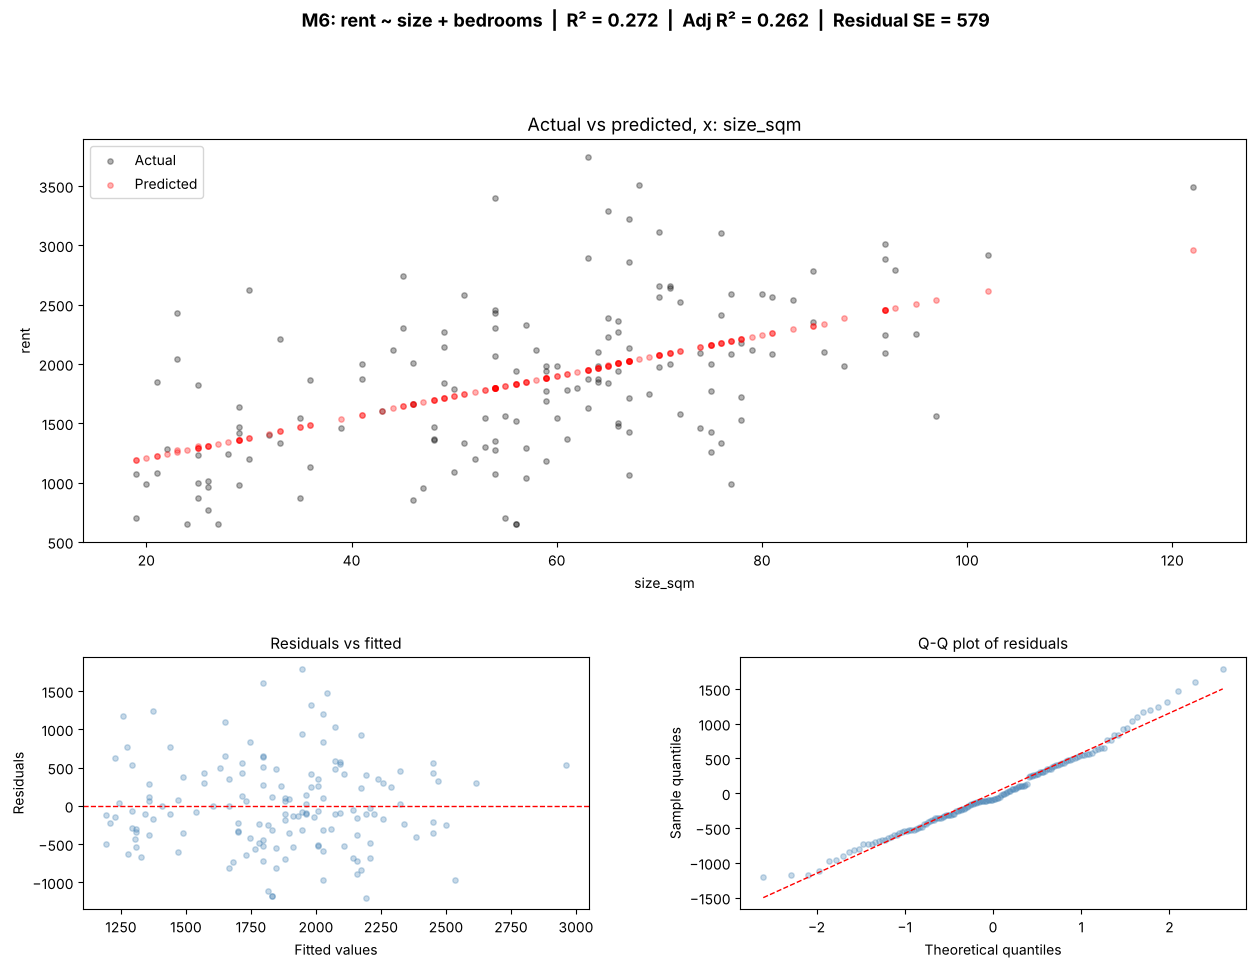

In [25]:
model6 = fit_and_plot('rent ~ size_sqm + bedrooms', data=rents,
                      model_name='M6: rent ~ size + bedrooms', x_var='size_sqm')

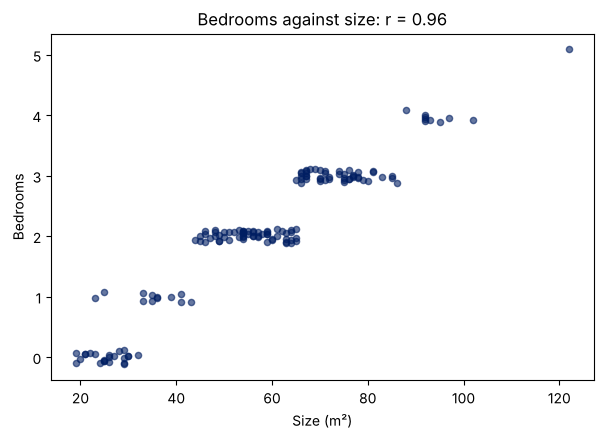

In [26]:
fig, ax = plt.subplots(figsize=(7, 4.5))
jitter = np.random.default_rng(1).uniform(-0.12, 0.12, len(rents))
ax.scatter(rents['size_sqm'], rents['bedrooms'] + jitter, alpha=0.6, s=20, color='#001e62')
ax.set_xlabel('Size (m²)'); ax.set_ylabel('Bedrooms')
ax.set_title(f"Bedrooms against size: r = {rents['size_sqm'].corr(rents['bedrooms']):.2f}")
plt.show()

### Section 11a: VIF check

VIF measures how much a coefficient's variance is inflated by its correlation with the other predictors.

- VIF below 5: no concern
- VIF 5 to 10: moderate concern
- **VIF above 10: serious collinearity**

For two predictors, VIF = 1 / (1 − r²), so with r = 0.96 we expect about 12.

In [27]:
X_vif = sm.add_constant(rents[['size_sqm', 'bedrooms']])
vif_data = pd.DataFrame({
    'feature': X_vif.columns[1:],
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(1, X_vif.shape[1])]
}).round(1)
vif_data

,feature,VIF
0,size_sqm,11.6
1,bedrooms,11.6


In [28]:
print(f"{'':<22}{'size coef':>10}{'size SE':>10}{'Adj R²':>9}")
print(f"{'M1: size':<22}{model1.params['size_sqm']:>10.2f}{model1.bse['size_sqm']:>10.2f}{model1.rsquared_adj:>9.3f}")
print(f"{'M6: size + bedrooms':<22}{model6.params['size_sqm']:>10.2f}{model6.bse['size_sqm']:>10.2f}{model6.rsquared_adj:>9.3f}")

                       size coef   size SE   Adj R²
M1: size                   17.22      2.32    0.267
M6: size + bedrooms        16.53      7.91    0.262


### Finding

The standard error on size more than triples (2.3 to 7.9), bedrooms looks worthless (p ≈ 0.93), and adjusted R² goes down. The two variables carry the same information, so the model cannot split the credit between them. **Fix:** keep one of them.

**A twist.** In the full model, bedrooms comes out *negative* (about −£177, p ≈ 0.14). Holding size fixed, more bedrooms means smaller rooms. Read signs in a collinear model with care.

In [29]:
model4_bed = smf.ols(full + ' + bedrooms', data=rents).fit()
print(model4_bed.params[['size_sqm', 'bedrooms']].round(1))
print(model4_bed.pvalues[['bedrooms']].round(3))

size_sqm     29.1
bedrooms   -177.0
dtype: float64
bedrooms    0.143
dtype: float64


## Section 12 (optional): Model 7, interactions

So far every line has been parallel: a dummy shifts the line but never changes its slope. Interactions let one effect depend on another.

- `size_sqm:furnished`: does an extra m² add more in a furnished listing?
- `parking:zone`: is parking worth more where it is scarce?

In a formula, `a:b` adds just the interaction and `a*b` adds both main effects and the interaction.

In [30]:
model_sf = smf.ols('rent ~ size_sqm * furnished', data=rents).fit()
b = model_sf.params
print(model_sf.summary().tables[1])
print(f"\nSlope, unfurnished: £{b['size_sqm']:.1f} per m²")
print(f"Slope, furnished:   £{b['size_sqm'] + b['size_sqm:furnished[T.Yes]']:.1f} per m²")

                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                  1076.8004    176.319      6.107      0.000     728.334    1425.267
furnished[T.Yes]           -390.0088    274.463     -1.421      0.157    -932.442     152.425
size_sqm                     11.2296      2.989      3.757      0.000       5.323      17.136
size_sqm:furnished[T.Yes]    11.7344      4.468      2.626      0.010       2.905      20.564

Slope, unfurnished: £11.2 per m²
Slope, furnished:   £23.0 per m²


In [31]:
model7 = smf.ols(full + ' + size_sqm:furnished + parking:zone', data=rents).fit()
print(f"Adjusted R², M4: {model4.rsquared_adj:.3f}")
print(f"Adjusted R², M7: {model7.rsquared_adj:.3f}")

# Is the set of three parking × zone terms worth having? A joint F test.
print(model7.f_test('parking[T.Yes]:zone[T.2] = parking[T.Yes]:zone[T.3] = parking[T.Yes]:zone[T.4] = 0'))

Adjusted R², M4: 0.673
Adjusted R², M7: 0.727
<F test: F=6.92186523305702, p=0.00022649288992438374, df_denom=136, df_num=3>


## Section 13: Model comparison

We compare the models two ways:

1. A small table of N, R², adjusted R², residual SE and AIC. Higher adjusted R², lower residual SE and lower AIC are better.
2. `summary_col()`, which lines the coefficients up by variable so you can see how each one moves as predictors are added. Watch the size slope: 17, then 16, then 26, then 21.5.

In [32]:
models = {
    'M1: size':            model1,
    'M2: + parking':       model2,
    'M2b: + parking, type': model2b,
    'M3: size + zone':     model3,
    'M4: full':            model4,
    'M5: + lucky':         model5,
    'M6: size + bedrooms': model6,
    'M7: + interactions':  model7,
}

comparison = pd.DataFrame({
    name: {
        'N':           int(m.nobs),
        'R2':          round(m.rsquared, 3),
        'Adj. R2':     round(m.rsquared_adj, 3),
        'Residual SE': round(m.scale ** 0.5, 0),
        'AIC':         round(m.aic, 1),
    }
    for name, m in models.items()
}).T
comparison

,N,R2,Adj. R2,Residual SE,AIC
M1: size,150.0,0.272,0.267,577.0,2335.0
M2: + parking,150.0,0.315,0.306,561.0,2327.8
"M2b: + parking, type",150.0,0.450,0.435,507.0,2299.0
M3: size + zone,150.0,0.560,0.548,453.0,2265.3
M4: full,150.0,0.693,0.673,385.0,2221.4
M5: + lucky,150.0,0.693,0.671,386.0,2223.4
M6: size + bedrooms,150.0,0.272,0.262,579.0,2337.0
M7: + interactions,150.0,0.751,0.727,352.0,2198.1


In [33]:
summary = summary_col(
    [model1, model2, model3, model4, model5],
    stars=True,
    float_format='%0.1f',
    model_names=['M1', 'M2', 'M3', 'M4', 'M5'],
    info_dict={'Residual SE': lambda x: f"{x.scale ** 0.5:.0f}",
               'Adj. R2':     lambda x: f"{x.rsquared_adj:.3f}"}
)
print(summary)


                    M1       M2        M3         M4         M5    
-------------------------------------------------------------------
Intercept        866.3*** 821.8*** 992.8***   930.7***   945.9***  
                 (141.2)  (138.1)  (118.9)    (160.9)    (173.9)   
size_sqm         17.2***  15.7***  26.4***    21.5***    21.5***   
                 (2.3)    (2.3)    (2.1)      (2.8)      (2.8)     
parking[T.Yes]            288.6***            295.1***   298.4***  
                          (94.3)              (70.1)     (71.7)    
zone[T.2]                          -564.6***  -497.5***  -498.6*** 
                                   (105.4)    (91.5)     (92.0)    
zone[T.3]                          -929.2***  -829.3***  -831.0*** 
                                   (112.8)    (104.4)    (105.0)   
zone[T.4]                          -1183.0*** -1102.7*** -1103.0***
                                   (132.0)    (126.7)    (127.1)   
type[T.House]                                 3

## Section 14: Using the model to predict

Predict the rent of a 60 m² unfurnished flat in zone 2, with no parking, 8 minutes from the tube. Compare the range with what size alone gave us in Section 7.

In [34]:
listing = pd.DataFrame({'size_sqm': [60], 'zone': ['2'], 'type': ['Flat'],
                        'furnished': ['No'], 'parking': ['No'], 'mins_to_tube': [8]})
pred4 = model4.get_prediction(listing).summary_frame(alpha=0.05)
rse4 = np.sqrt(model4.mse_resid)
p = pred4['mean'].iloc[0]

print(f"Predicted rent: £{p:,.0f}")
print(f"Rule of thumb, ± 2 × {rse4:.0f}: £{p - 2*rse4:,.0f} to £{p + 2*rse4:,.0f}")
print(f"Exact 95% prediction interval: £{pred4['obs_ci_lower'].iloc[0]:,.0f} to £{pred4['obs_ci_upper'].iloc[0]:,.0f}")
print(f"\nWidth with size only:  £{pred['obs_ci_upper'].iloc[0] - pred['obs_ci_lower'].iloc[0]:,.0f}")
print(f"Width with full model: £{pred4['obs_ci_upper'].iloc[0] - pred4['obs_ci_lower'].iloc[0]:,.0f}")

Predicted rent: £1,705
Rule of thumb, ± 2 × 385: £935 to £2,475
Exact 95% prediction interval: £930 to £2,480

Width with size only:  £2,288
Width with full model: £1,550


## Your turn

1. Predict the rent of a 45 m² furnished studio in zone 1 with parking, 5 minutes from the tube. Report the point estimate and the 95% prediction interval.
2. Refit Model 4 with **House** as the base category for `type` (hint: `C(type, Treatment(reference='House'))`). Which numbers change, and which stay the same?
3. Add `size_sqm:zone` to Model 4. Does an extra square metre cost the same in every zone? Use adjusted R² and the p-values to decide.
4. Drop `mins_to_tube` from Model 4. What happens to adjusted R²? Would you keep it, and why?